## Load preprocessed adata

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import chi2
from sklearn.neighbors import NearestNeighbors
import scanpy as sc
import scanpy.external as sce
import os

In [ ]:
import sys
import os

# Get the path to the directory containing 'scripts/' 
# (assuming your notebook is in the project root or a sibling folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
scripts_path = os.path.join(project_root, "scripts")

if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

In [29]:
rev_n = 12
region = 'hippocampus' # cerebral_cortex, hippocampus, midbrain
path_to_data = f"/home/ratopin/big_data/nmr/{region}_nmr_adata_optimal{rev_n}.h5ad"

In [30]:
adata = sc.read_h5ad(path_to_data)
adata.obs_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 13634 × 17592
    obs: 'species', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_tf', 'log1p_total_counts_tf', 'pct_counts_tf', 'n_counts', 'qc_composite', 'qc_label', 'sample_id', 'replicate', 'leiden_1.0', 'leiden_5.0'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std', 'is_highly_variable'
    uns: 'hvg', 'is_highly_variable_colors', 'leiden_1.0

In [31]:
## get clusters from `subcluster.ipynb`
clusters =pd.read_csv(f"../../optimization/{region}_recursive_hpo_subclustering_labels.csv", index_col=0)
adata.obs['supercluster'] = clusters['supercluster'].astype('category')
adata.obs['cluster'] = clusters['cluster']
adata.obs['subcluster'] = clusters['subcluster']
print(f'Number of superclusters: {clusters['supercluster'].nunique()}')
print(f'Number of clusters: {clusters['cluster'].nunique()}')   
print(f'Number of subclusters: {clusters['subcluster'].nunique()}')

Number of superclusters: 6
Number of clusters: 50
Number of subclusters: 167


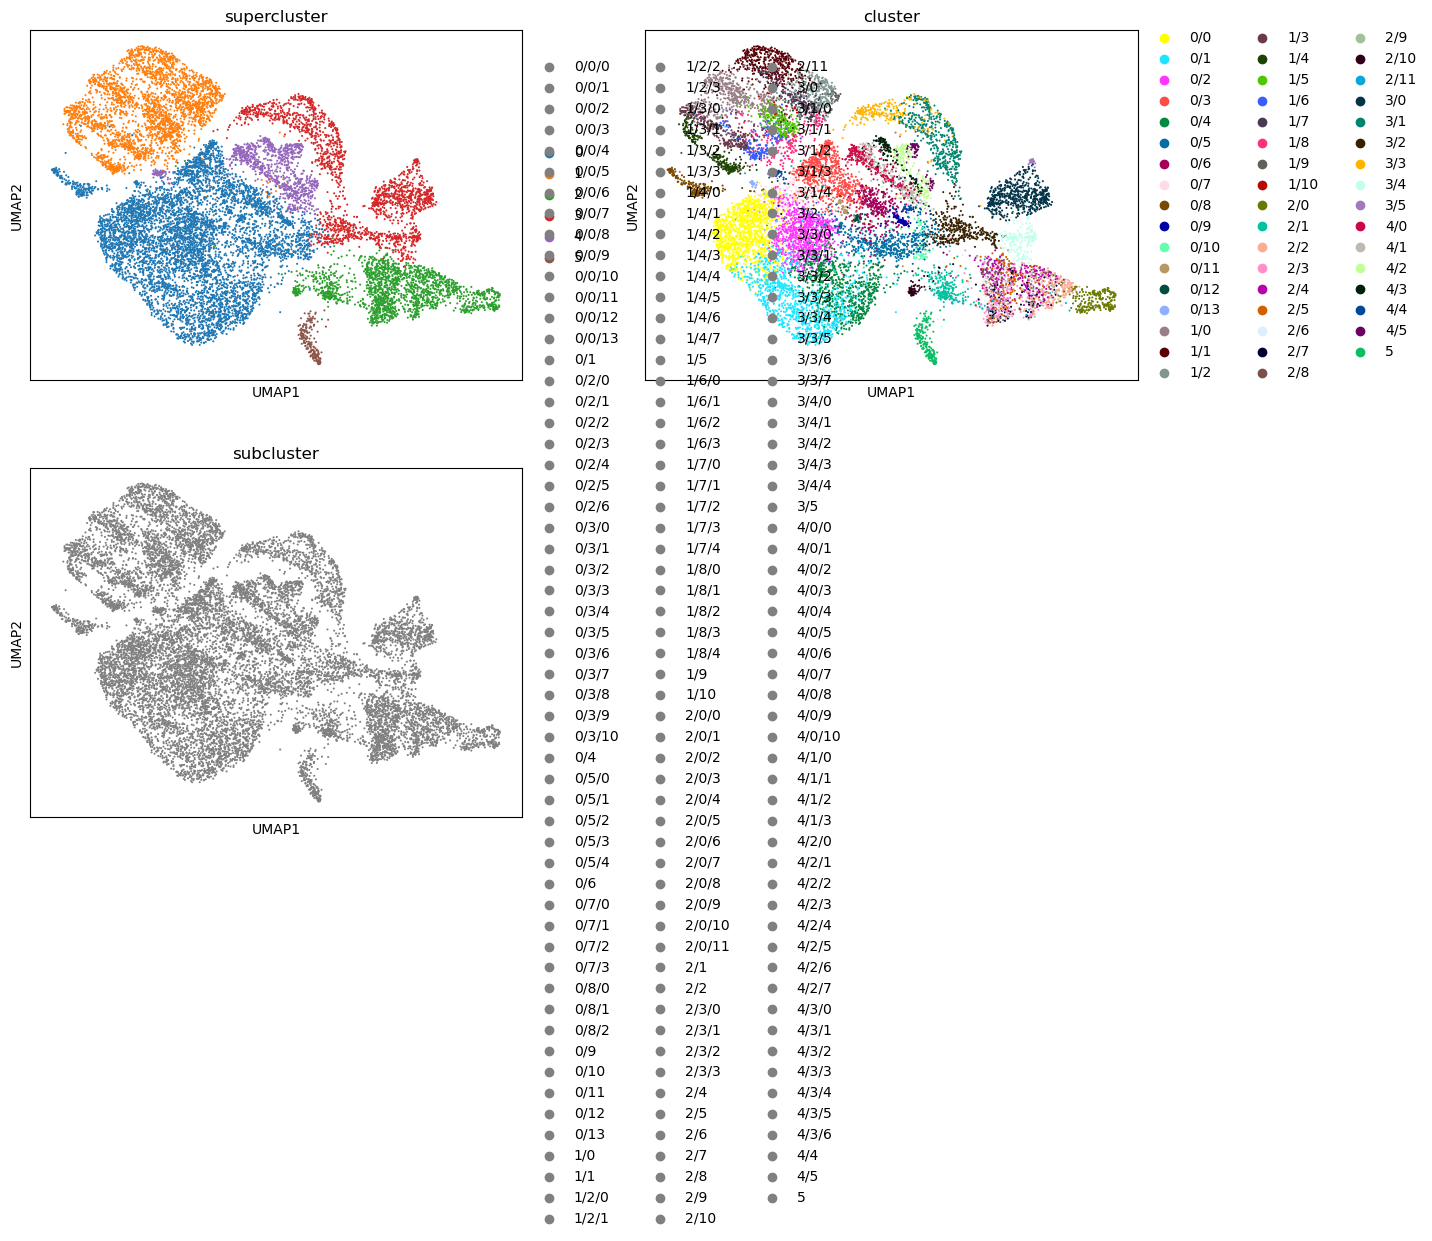

In [32]:
sc.pl.umap(adata, color=['supercluster', 'cluster','subcluster'], ncols=2)

### Get DEGs

In [33]:
sc.tl.rank_genes_groups(adata, groupby='cluster', method= 'wilcoxon')

/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value enco

In [34]:
sc.tl.filter_rank_genes_groups(adata, min_fold_change= 1.5, min_in_group_fraction=0.25,
    max_out_group_fraction=0.5)

In [35]:
df = sc.get.rank_genes_groups_df(
    adata,
    key="rank_genes_groups_filtered",group=None
)

In [36]:
df_all = sc.get.rank_genes_groups_df(
    adata,
    key="rank_genes_groups",group=None
)

## GSEA

In [37]:
from gseapy.plot import gseaplot
import gseapy as gp

In [38]:
print("gseapy v", gp.__version__)


gseapy v 1.1.11


In [39]:
gp.get_library_name()
#'Azimuth_Cell_Types_2021'
#'Allen_Brain_Atlas_10x_scRNA_2021'
#'Descartes_Cell_Types_and_Tissue_2021',
#'KEGG_2026'



['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'Carcinogenome',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popul

In [40]:
def run_gsea_on_group(clus_markers,gene_sets = 'Allen_Brain_Atlas_10x_scRNA_2021'):
    clus_markers['Rank'] = -np.log10(clus_markers.pvals_adj)*clus_markers['logfoldchanges']
    clus_markers = clus_markers.sort_values('Rank', ascending = False).reset_index(drop = True)
    ranking = clus_markers[['names', 'Rank']]
    pre_res = gp.prerank(rnk = ranking, gene_sets = 'Azimuth_Cell_Types_2021', seed = 6, permutation_num = 100, )
    out = []
    for term in list(pre_res.results):
        out.append([term,
                pre_res.results[term]['fdr'],
                pre_res.results[term]['es'],
                pre_res.results[term]['nes'],
                ])

    out_df = pd.DataFrame(out, columns = ['Term','fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)
    term_to_graph = out_df.iloc[0].Term
    gsea_plot = gseaplot(pre_res.ranking, term = term_to_graph, **pre_res.results[term_to_graph])
    return pre_res, out_df, term_to_graph, gsea_plot


In [41]:
from gseapy.plot import gseaplot, gseaplot2

In [42]:
def run_gsea_on_group(clus_markers,gene_sets = 'Allen_Brain_Atlas_10x_scRNA_2021'):
    clus_markers['Rank'] = -np.log10(clus_markers.pvals_adj)*clus_markers['logfoldchanges']
    clus_markers = clus_markers.sort_values('Rank', ascending = False).reset_index(drop = True)
    ranking = clus_markers[['names', 'Rank']]
    pre_res = gp.prerank(rnk = ranking, gene_sets = 'Azimuth_Cell_Types_2021', seed = 6, permutation_num = 100, )
    out = []
    for term in list(pre_res.results):
        out.append([term,
                pre_res.results[term]['fdr'],
                pre_res.results[term]['es'],
                pre_res.results[term]['nes'],
                ])

    out_df = pd.DataFrame(out, columns = ['Term','fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)
    term_to_graph = out_df.iloc[0].Term
    gsea_plot = gseaplot(pre_res.ranking, term = term_to_graph, **pre_res.results[term_to_graph])
    return pre_res, out_df, term_to_graph, gsea_plot


In [43]:
def run_gsea_on_group(
    clus_markers,
    gene_sets="Allen_Brain_Atlas_10x_scRNA_2021",
    min_perm=1000,
    seed=6,
):
    # Defensive copy
    clus_markers = clus_markers.copy()

    # Avoid log(0); Scanpy can produce pvals_adj == 0
    eps = 1e-300
    clus_markers["Rank"] = (
        -np.log10(clus_markers["pvals_adj"].clip(lower=eps))
        * clus_markers["logfoldchanges"]
    )

    # Remove invalid entries
    clus_markers = (
        clus_markers
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["names", "Rank"])
        .drop_duplicates(subset="names")
        .sort_values("Rank", ascending=False)
        .reset_index(drop=True)
    )

    ranking = clus_markers[["names", "Rank"]]

    pre_res = gp.prerank(
        rnk=ranking,
        gene_sets=gene_sets,
        seed=seed,
        permutation_num=min_perm,
        verbose=False,
    )

    if not pre_res.results:
        return pre_res, pd.DataFrame(), None, None

    out_df = (
        pd.DataFrame.from_dict(pre_res.results, orient="index")
        .reset_index(names="Term")
        .loc[:, ["Term", "fdr", "es", "nes"]]
        .sort_values("fdr", na_position="last")
        .reset_index(drop=True)
    )

    # Safely pick top term
    term_to_graph = out_df.loc[out_df["fdr"].notna(), "Term"].iloc[0]
    res = pre_res.results[term_to_graph]
    
    assert term_to_graph in pre_res.results
    assert isinstance(pre_res.ranking, (pd.Series, pd.DataFrame, np.ndarray))


    try: 
        gsea_plot = gseaplot(
            term=term_to_graph,
            hits=res["hits"],
            nes=res["nes"],
            pval=res["pval"],
            fdr=res["fdr"],
            RES=res["RES"],
            rank_metric=pre_res.ranking)
    except:
        gsea_plot = gseaplot2(
            terms=[term_to_graph],
            hits=[res["hits"]],
            RESs=[res["RES"]],
            rank_metric=pre_res.ranking,
        )

    return pre_res, out_df, term_to_graph, gsea_plot


2026-05-25 20:59:42,092 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-25 20:59:49,205 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-25 20:59:51,522 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-25 20:59:57,360 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-25 21:00:10,671 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-05-25 21:00:13,787 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be

PanicException: called `Option::unwrap()` on a `None` value

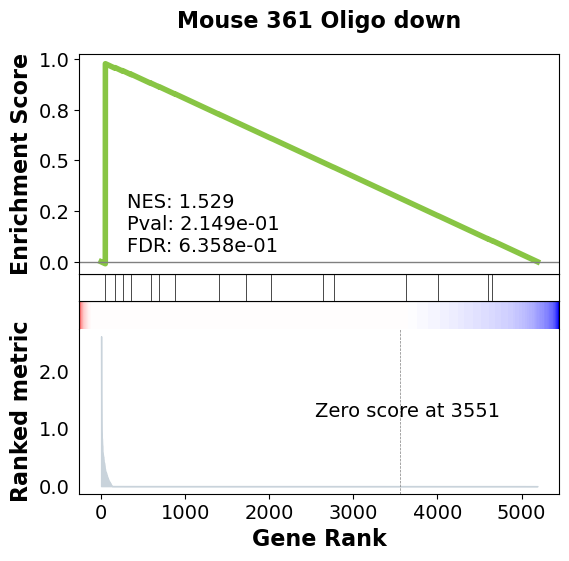

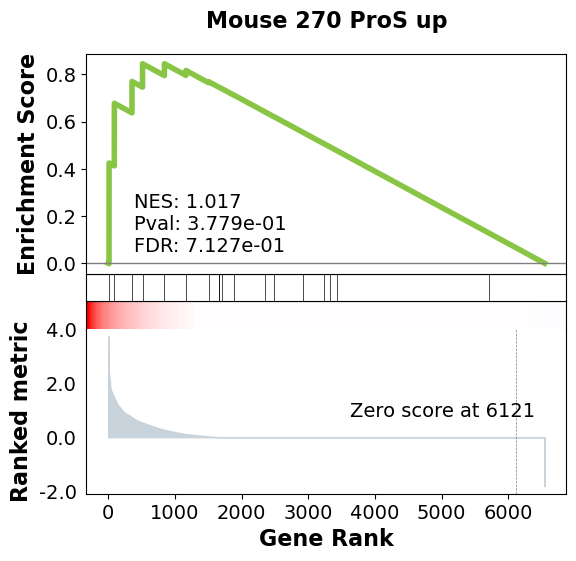

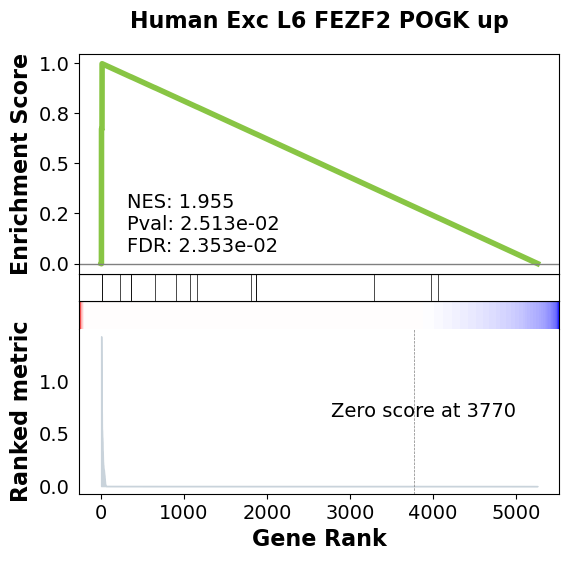

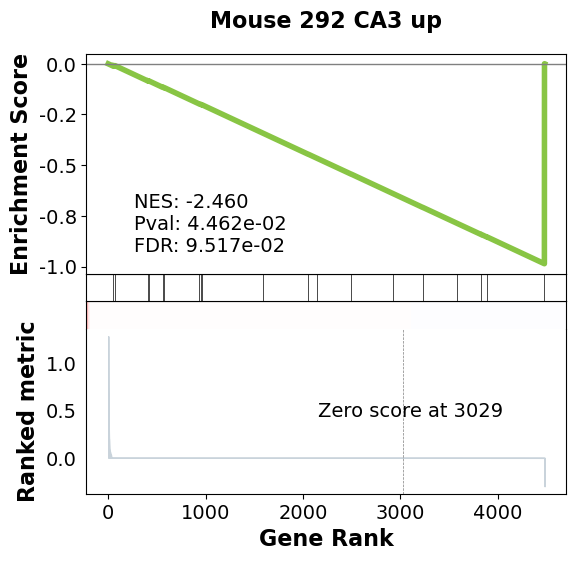

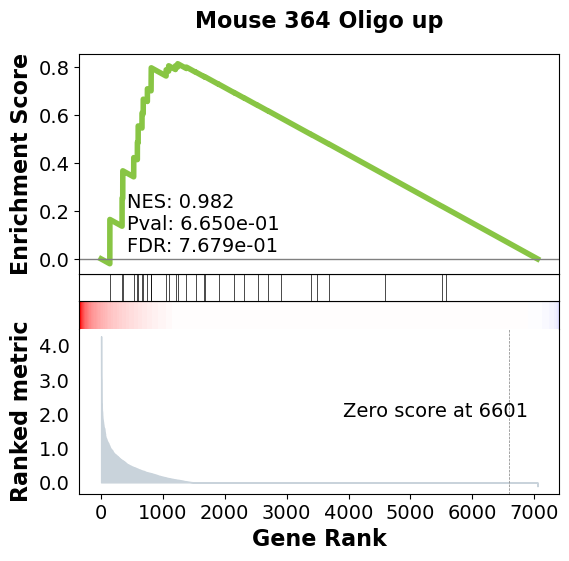

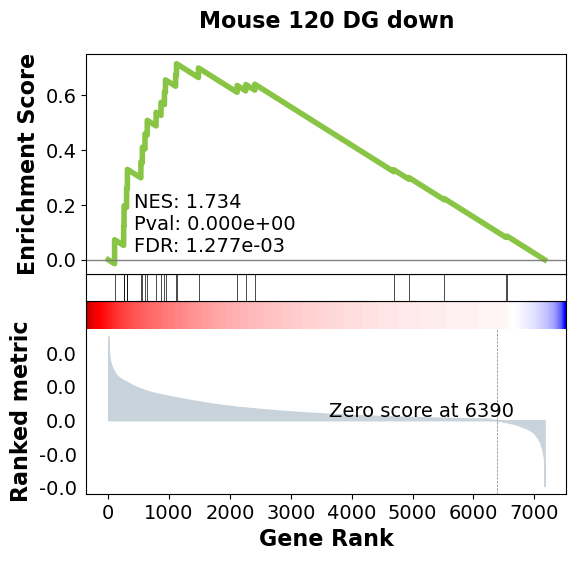

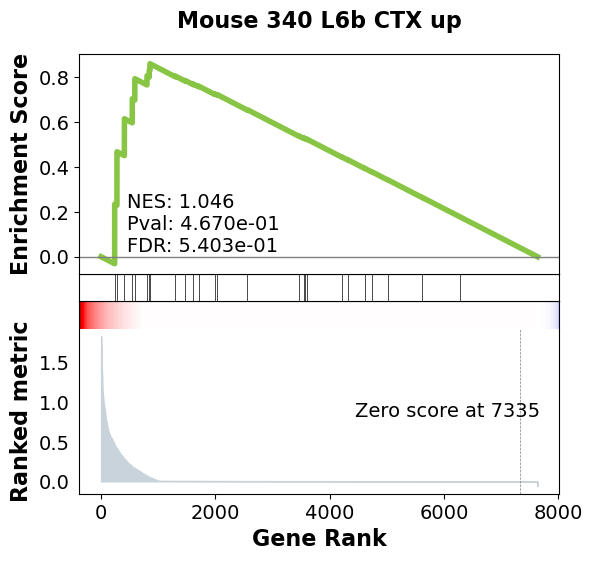

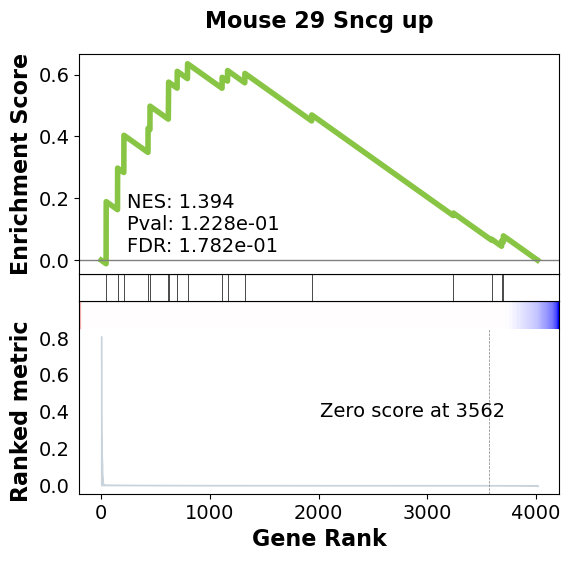

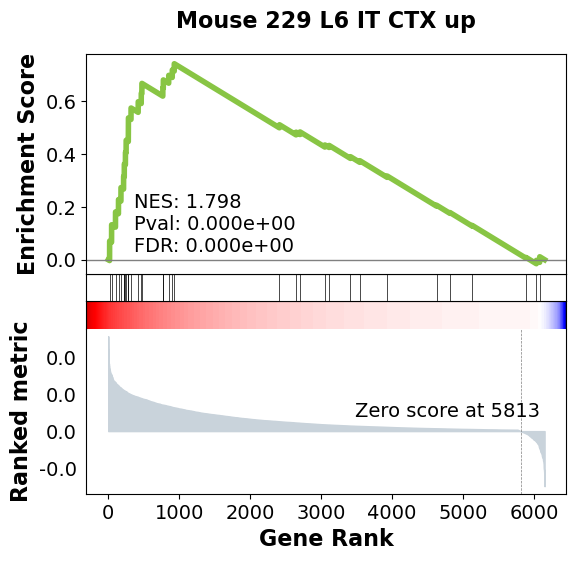

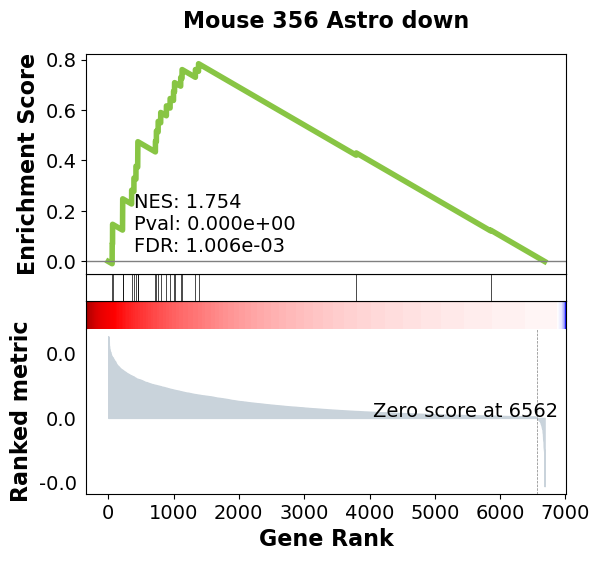

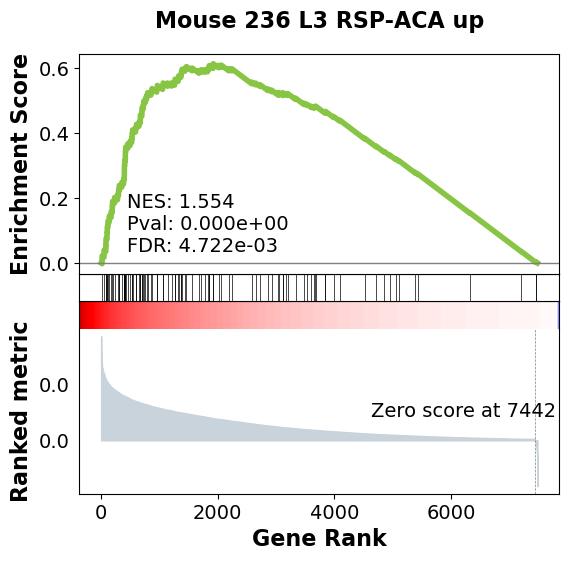

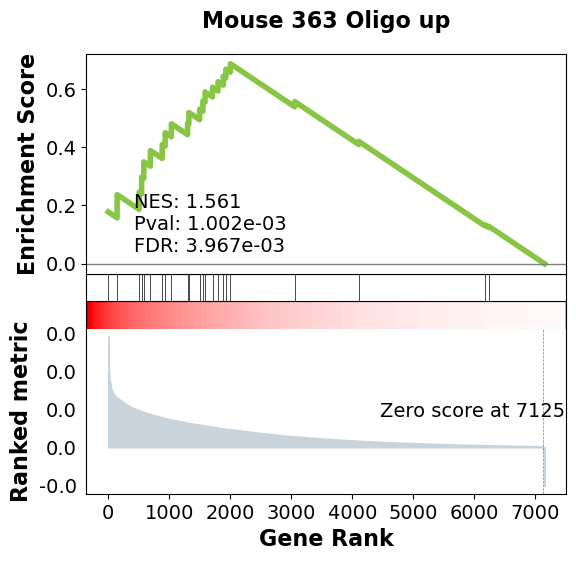

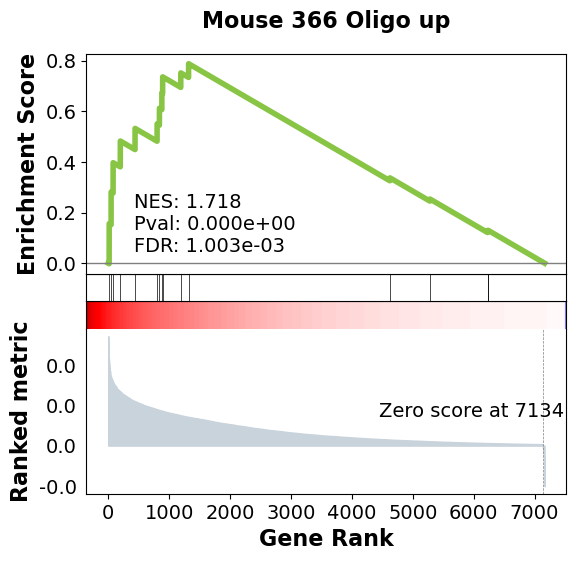

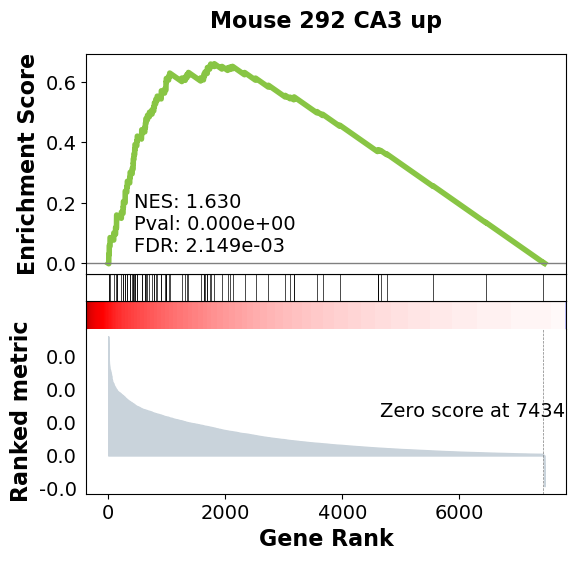

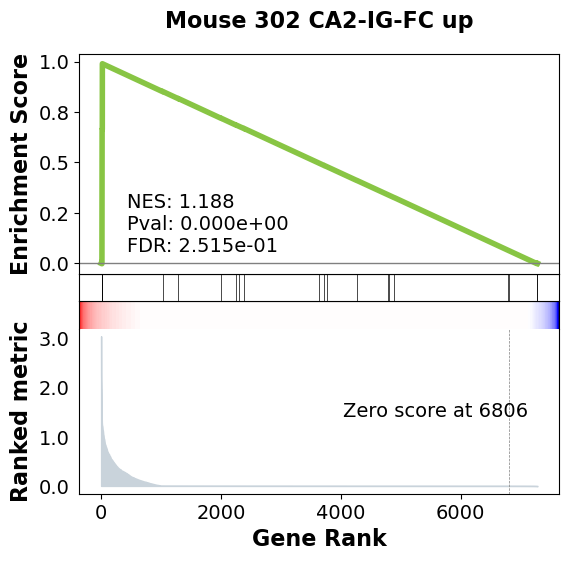

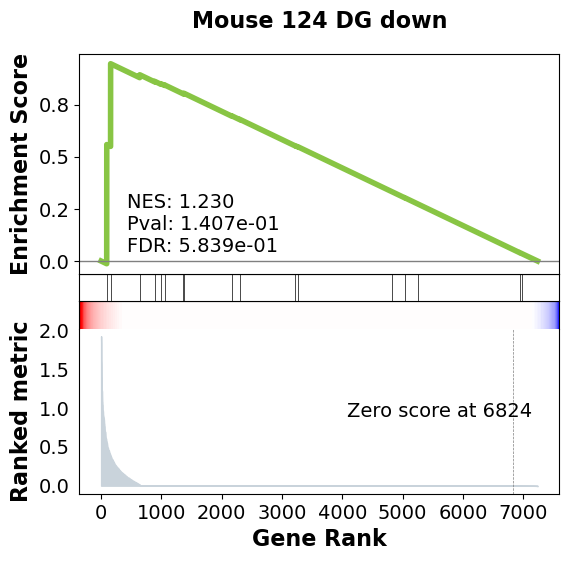

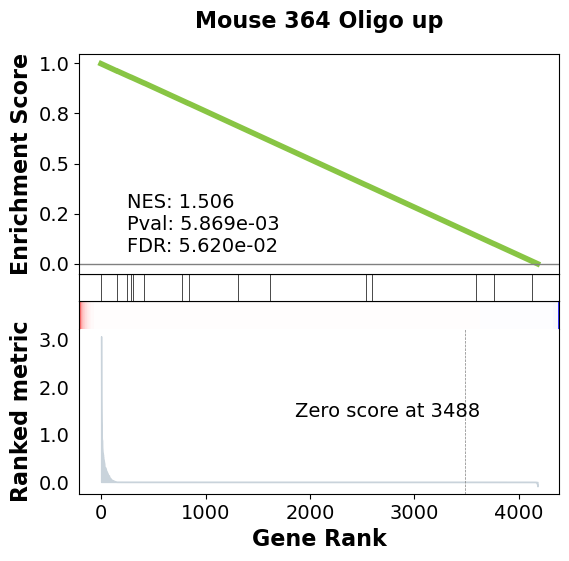

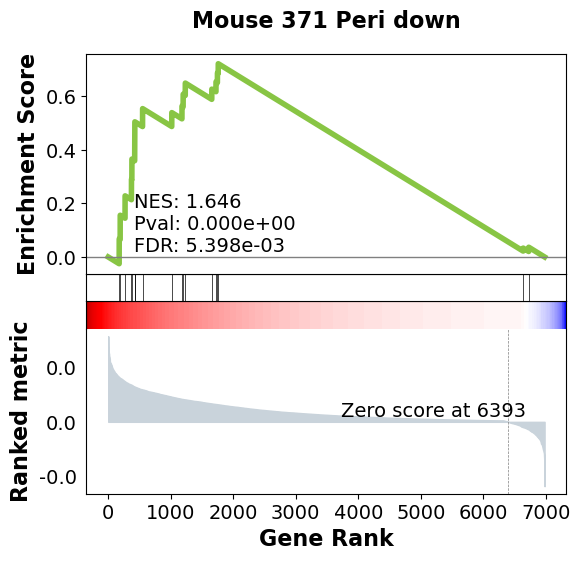

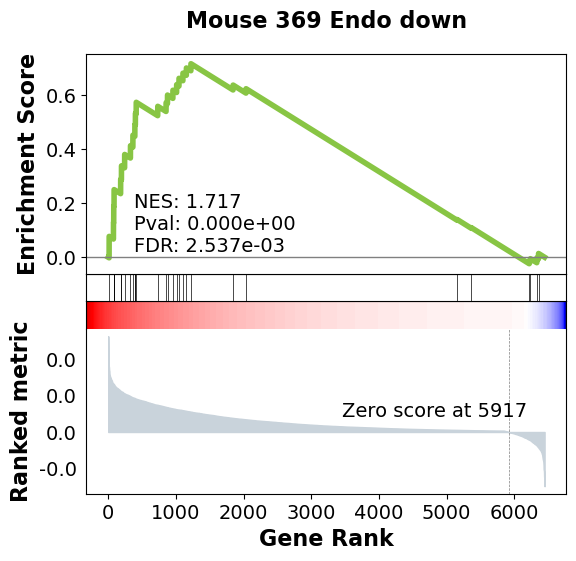

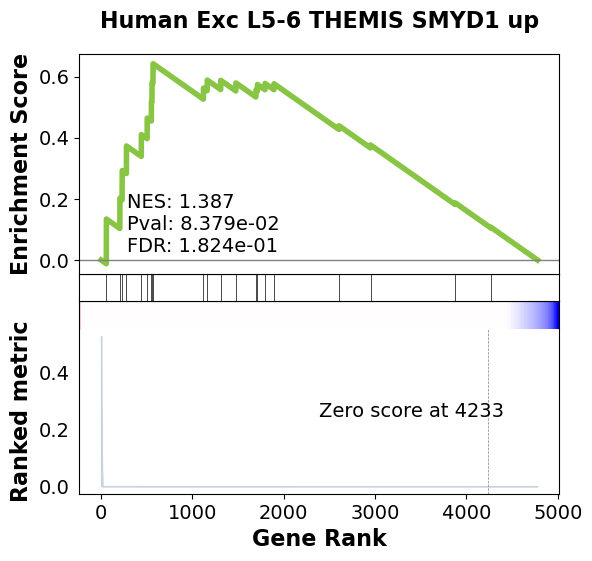

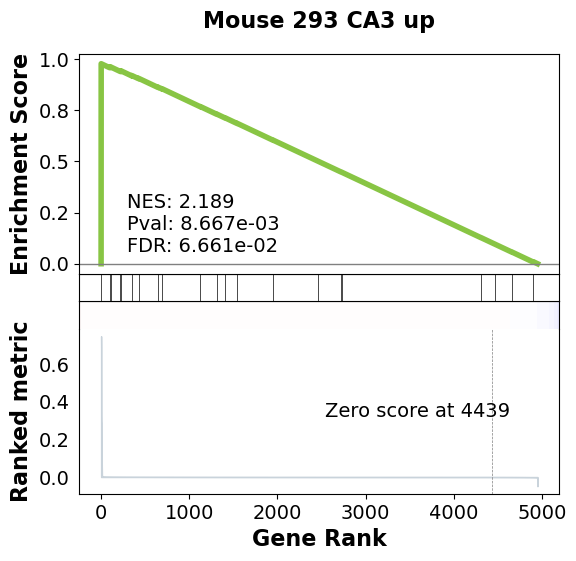

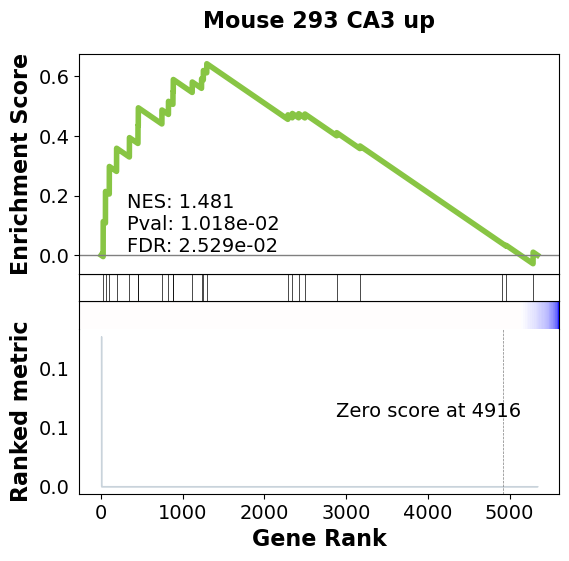

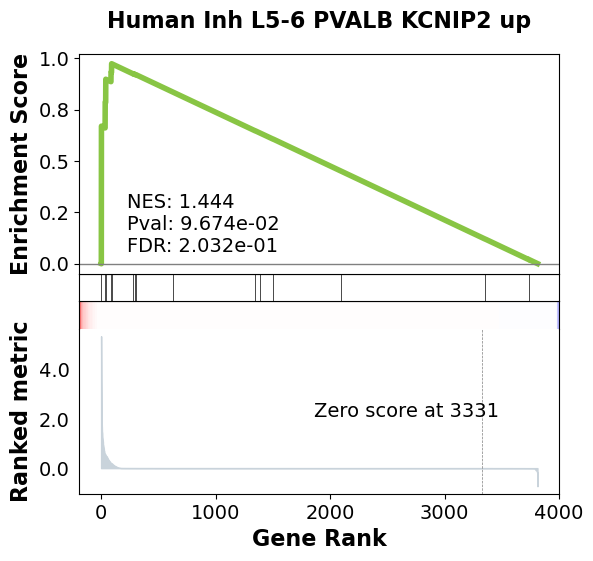

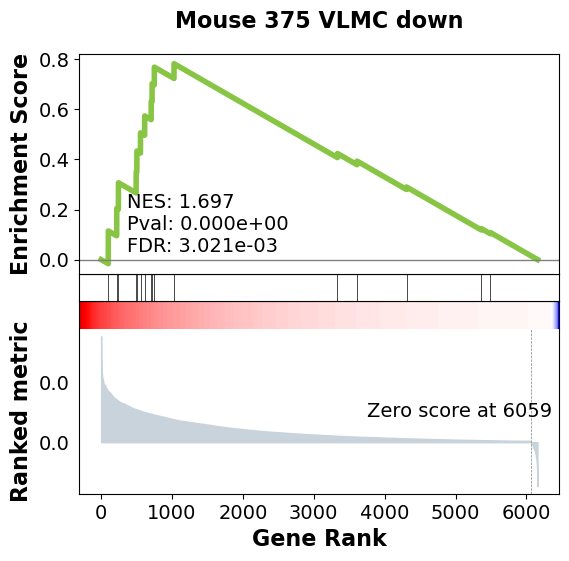

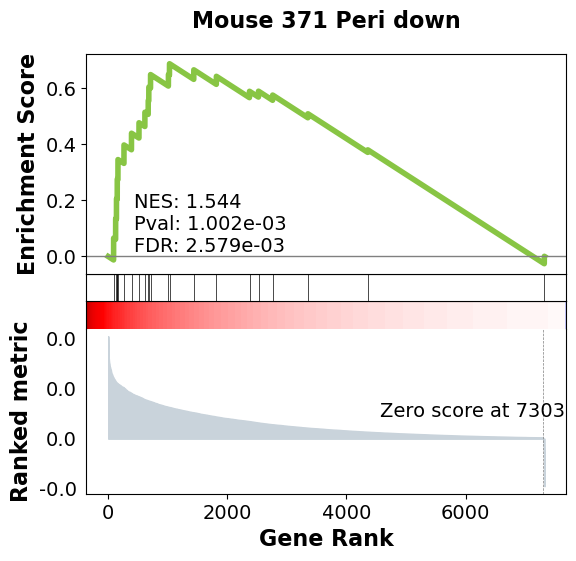

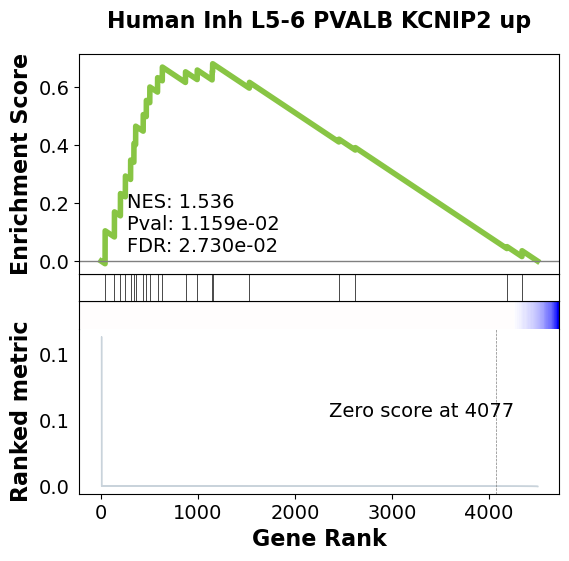

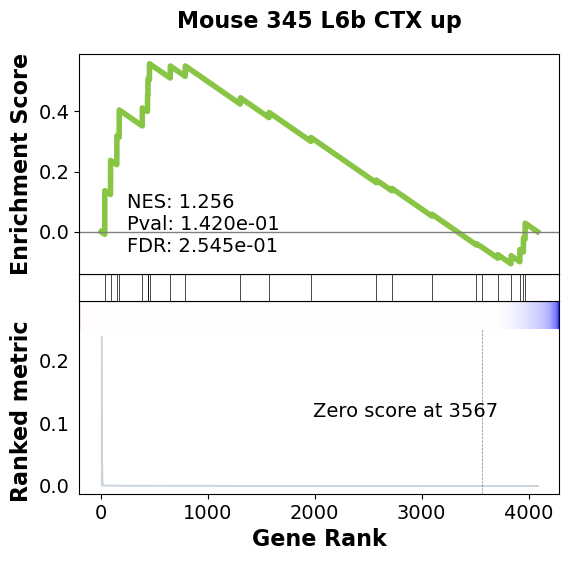

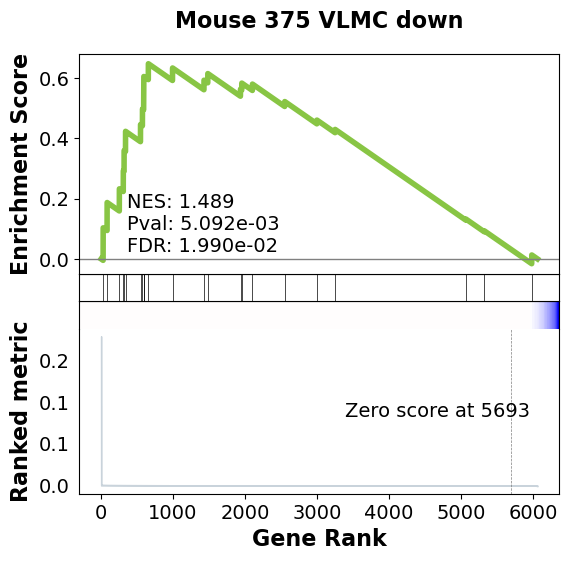

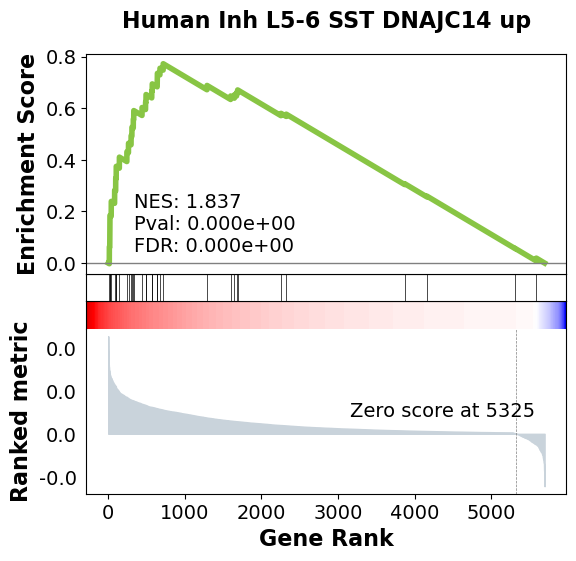

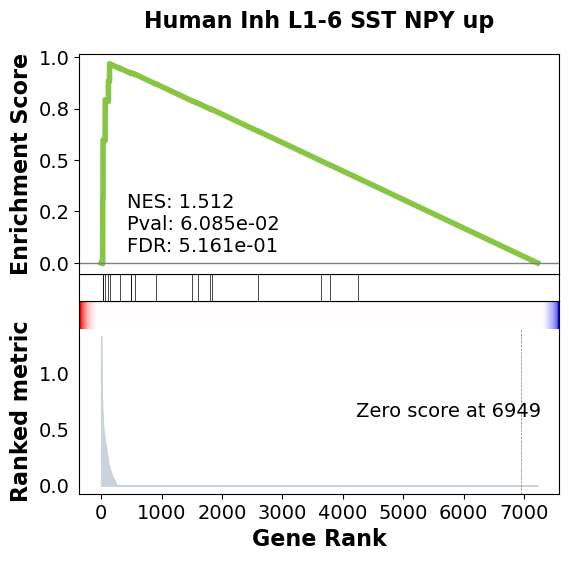

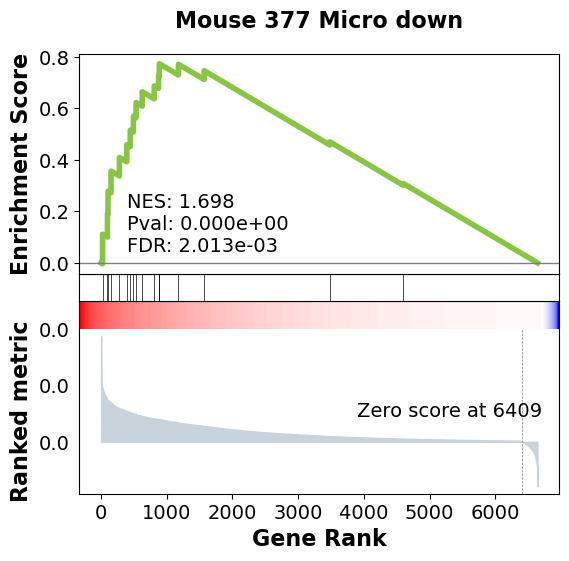

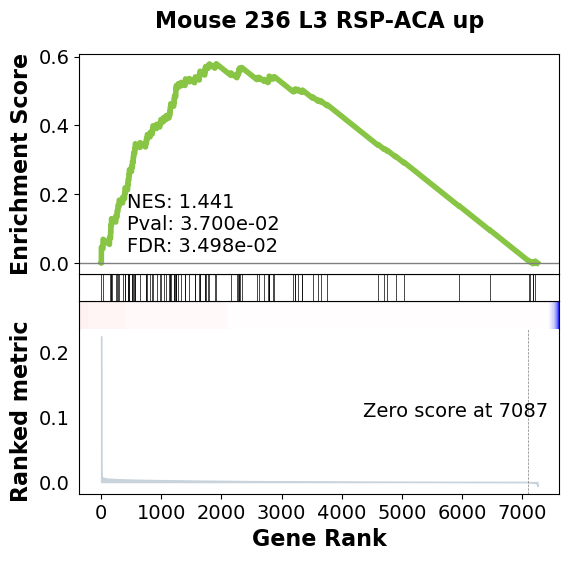

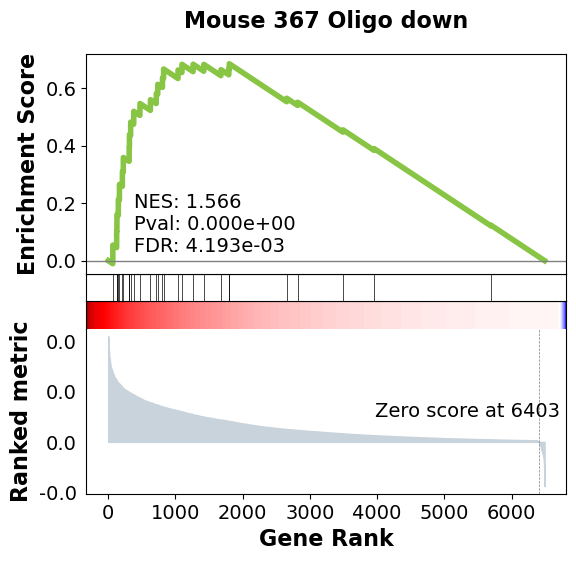

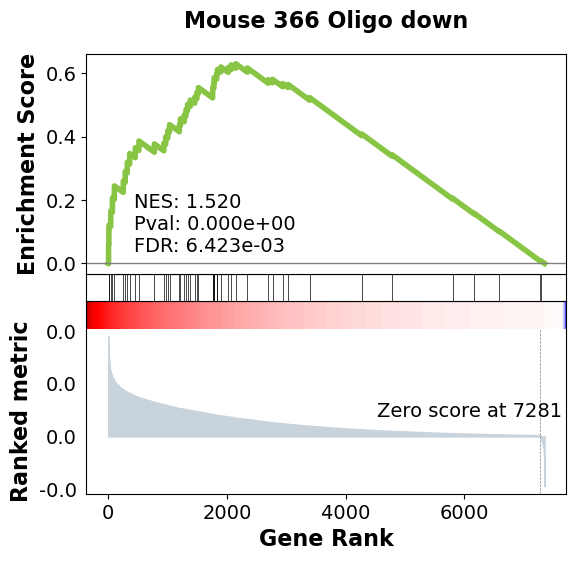

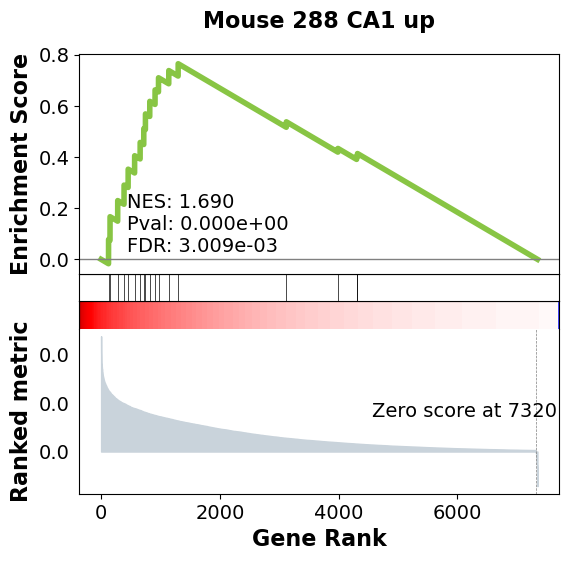

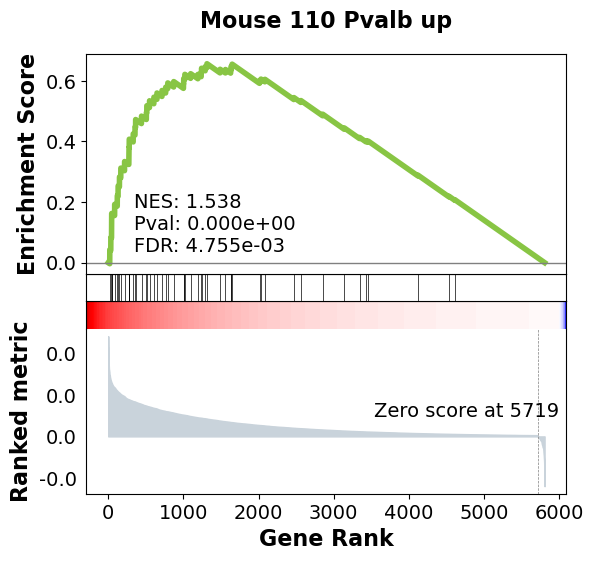

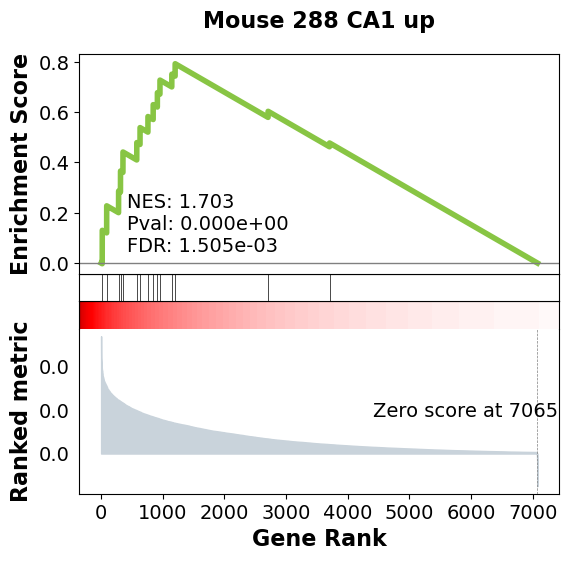

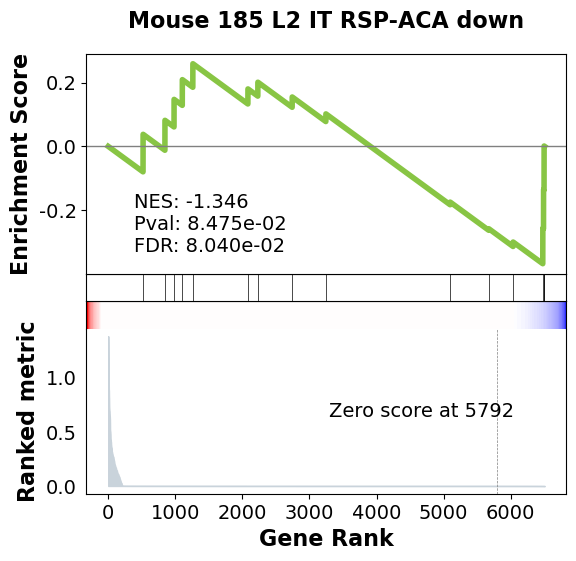

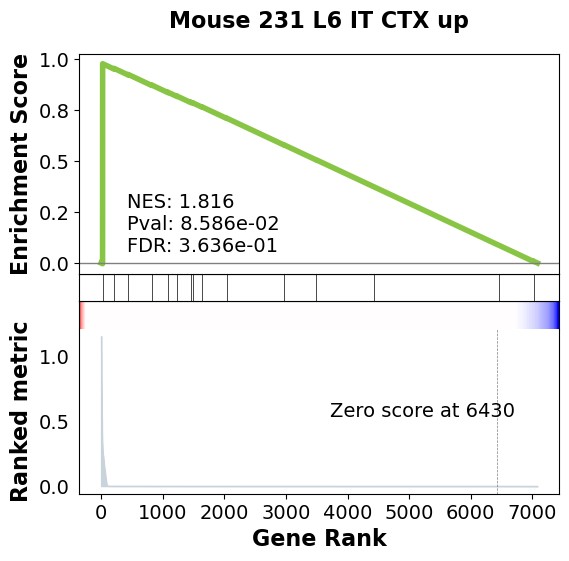

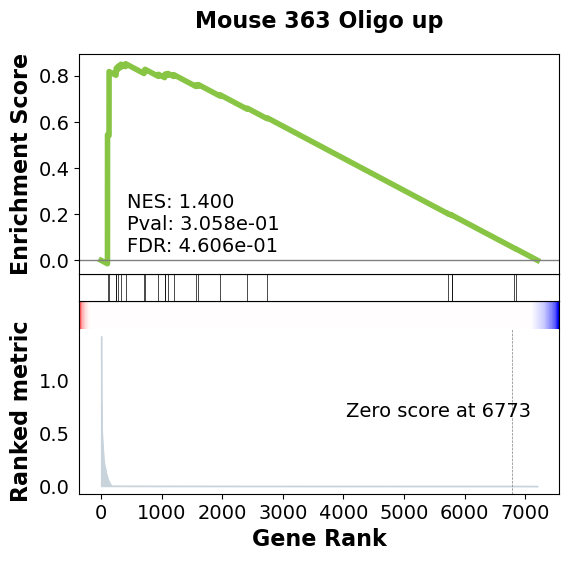

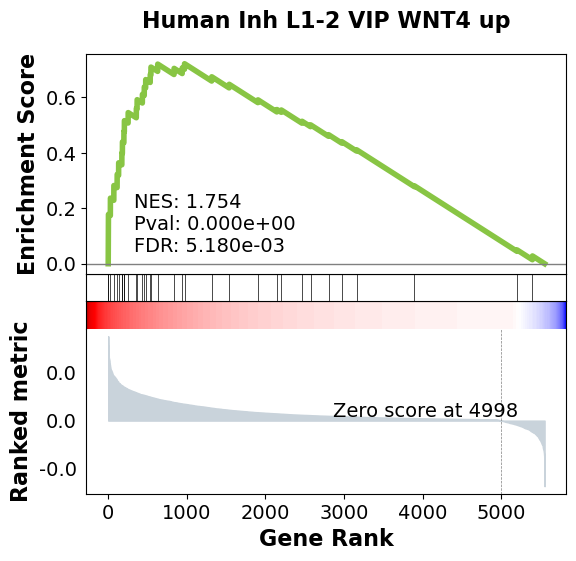

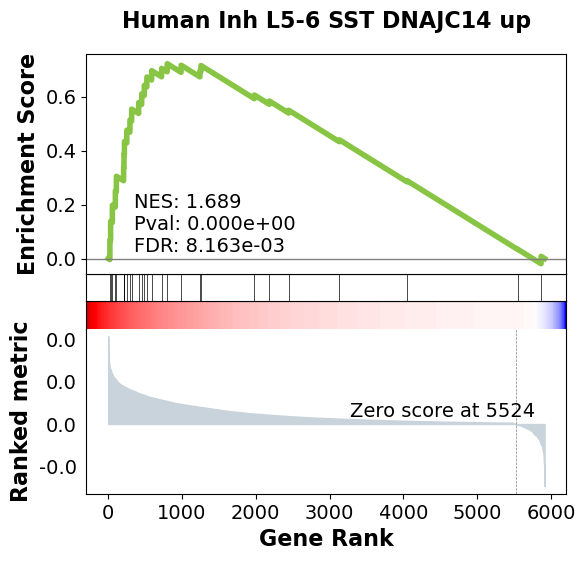

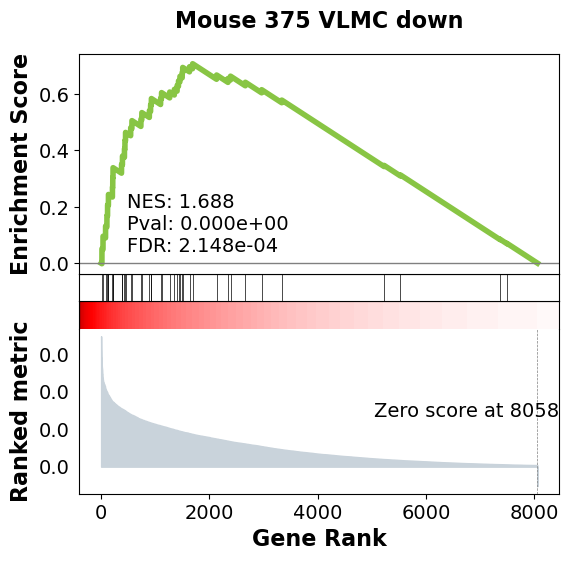

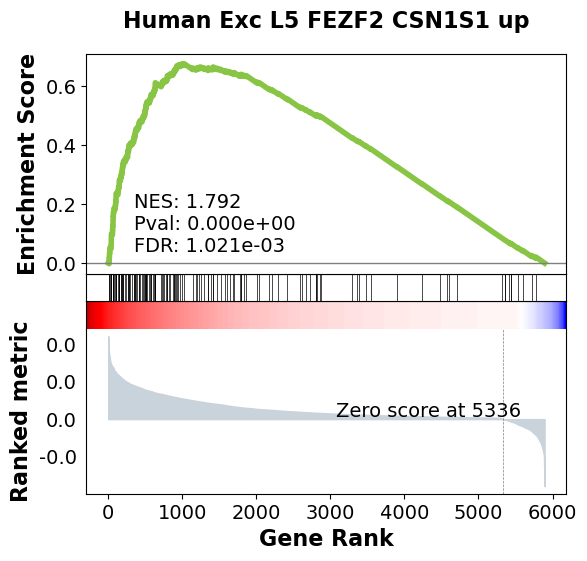

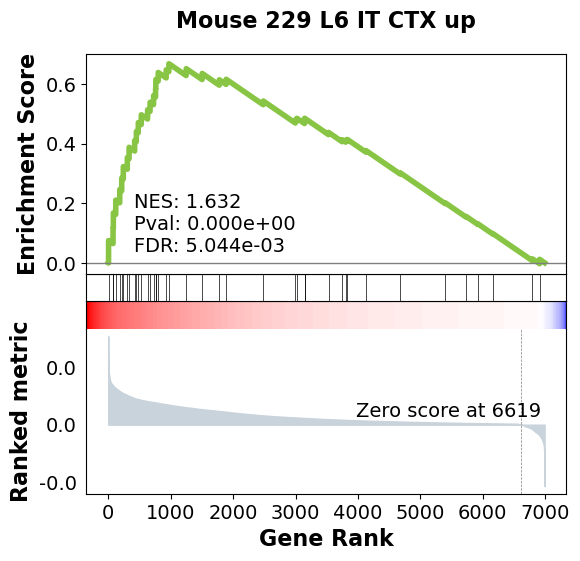

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from math import ceil

# Store outputs
all_results = {}

for group in df_all.group.unique():
    pre_res, out_df, term_to_graph, _ = run_gsea_on_group(
        df_all[df_all.group == group],
        gene_sets="Allen_Brain_Atlas_10x_scRNA_2021",
    )

    if term_to_graph is not None:
        all_results[group] = {
            "pre_res": pre_res,
            "term": term_to_graph,
        }


# ---------- GRID PLOT ----------
n = len(all_results)
ncols = 3
nrows = ceil(n / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6 * ncols, 4 * nrows),
)

axes = np.array(axes).flatten()

for ax, (group, d) in zip(axes, all_results.items()):

    pre_res = d["pre_res"]
    term = d["term"]
    res = pre_res.results[term]

    # enrichment score
    ax.plot(res["RES"], linewidth=2)

    # gene hits
    ymin, ymax = ax.get_ylim()
    ax.vlines(
        res["hits"],
        ymin,
        ymin + (ymax - ymin) * 0.15,
        linewidth=0.4,
    )

    ax.axhline(0, linestyle="--", linewidth=0.8)

    ax.set_title(
        f"Cluster {group}\n"
        f"{term[:50]}\n"
        f"NES={res['nes']:.2f}, FDR={res['fdr']:.2e}",
        fontsize=9,
    )

    ax.set_xlabel("Rank")
    ax.set_ylabel("ES")

# Hide unused panels
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1383690/1357505503.py:8: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


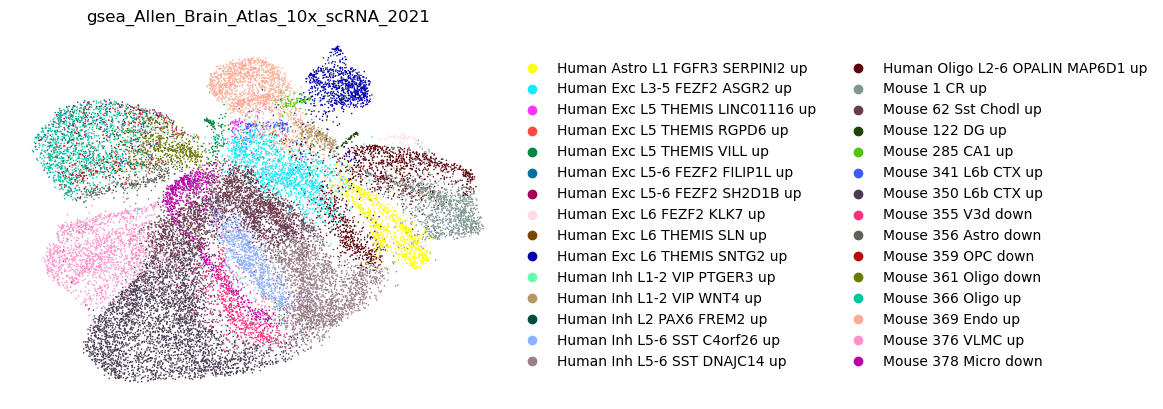

In [ ]:
# Add predictions into adata.obs
adata.obs["gsea_Allen_Brain_Atlas_10x_scRNA_2021"] = (
    adata.obs["cluster"]
    .astype(str)
    .map(cluster_to_term)
)

sc.pl.umap(
    adata,
    color="gsea_Allen_Brain_Atlas_10x_scRNA_2021",
    legend_loc="right margin",
    frameon=False,
    save=f"_{region}_gsea_Allen_Brain_Atlas_10x_scRNA_2021_umap.png",
)

In [ ]:
adata.obs[['cluster', 'gsea_Allen_Brain_Atlas_10x_scRNA_2021']].to_csv(f"{region}_cluster_gsea_Allen_Brain_Atlas_10x_scRNA_2021.csv", index=True)